In [1]:
import sys
import json
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root whether launched from repo root or Notebooks/
repo_root = Path.cwd().resolve()
if not (repo_root / "backtesting" / "renquant_102").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import common

# ── Strategy configuration ───────────────────────────────────────────────
STRATEGY_DIR = repo_root / "backtesting" / "renquant_102"
MODELS_DIR = STRATEGY_DIR / "models"
config = common.load_strategy_config(STRATEGY_DIR / "strategy_config.json")

WATCHLIST = config["watchlist"]
BENCHMARK = config.get("benchmark", "SPY")
MODEL_NAME = config["model_name"]
PROVIDER = config["data_src"]

# Dynamic 2-year window ending today
END = str(date.today())
START = str(date.today() - timedelta(days=365 * int(config.get("training_years", 2))))

# Walk-forward OOS validation: train on first TRAIN_SPLIT, test on remainder
TRAIN_SPLIT = float(config.get("train_split", 0.70))

# Full indicator spec — all available indicators computed upfront.
INDICATOR_SPEC = {
    "rsi":         {"period": 14},
    "macd":        {"fast": 12, "slow": 26, "signal": 9},
    "cci":         {"period": 20},
    "bbp":         {"period": 20},
    "stochastic":  {"window": 14, "smooth": 3},
    "adx":         {"period": 14},
    "atr":         {"period": 14},
    "obv":         {"signal_period": 20},
    "williams_r":  {"period": 14},
    "ema":         {"period": 50},
    "momentum":    {"period": 10},
}

# Shared feature columns for Classification models.
FEATURE_COLUMNS = ["rsi", "macd_hist", "cci", "bbp", "adx", "williams_r", "obv_slope"]
RATIO_FEATURES = {"rsi", "adx"}
DIFF_FEATURES  = {"macd_hist", "cci", "bbp", "williams_r", "obv_slope"}

# Q-Learning uses trend features (3 features x 5 bins = 375 states)
QL_FEATURE_COLUMNS = ["trend", "rel_mom_20d", "macd_hist"]

# ── Simulation parameters (from config) ──────────────────────────────────
INITIAL_CASH = 10_000
WASH_SALE_DAYS = config.get("wash_sale_days", 30)
MIN_HOLD_DAYS = config.get("min_hold_days", 20)
MAX_HOLD_DAYS = config.get("max_hold_days", 150)
pos_sizing = config.get("position_sizing", {})
MAX_POSITION_PCT = pos_sizing.get("max_position_pct", 0.33)
CASH_RESERVE_PCT = pos_sizing.get("cash_reserve_pct", 0.10)

# ── Approach configurations ──────────────────────────────────────────────
DUAL_MOM_RULES = [
    {"col": "trend",       "buy_above": 1.0,    "sell_below": 0.97},
    {"col": "trend_long",  "buy_above": 1.0,    "sell_below": 0.97},
    {"col": "rel_mom_20d", "buy_above": 0.0,    "sell_below": -0.03},
    {"col": "rel_mom_60d", "buy_above": 0.0,    "sell_below": -0.05},
    {"col": "macd_hist",   "buy_above": 0,       "sell_below": 0},
    {"col": "obv_slope",   "buy_above": 0,       "sell_below": 0},
]

CLASSIFICATION_PARAMS = {
    "feature_columns": FEATURE_COLUMNS,
    "lookahead": 10,
    "threshold": 0.04,
    "leaf_size": 25,
    "bags": 15,
    "buy_threshold": 0.1,
    "sell_threshold": -0.1,
}

QLEARNING_PARAMS = {
    "feature_columns": QL_FEATURE_COLUMNS,
    "n_bins": 5,
    "n_epochs": 500,
    "alpha": 0.15,
    "gamma": 0.95,
    "rar": 0.99,
    "radr": 0.9995,
    "dyna": 0,
}

print(f"Strategy:    {MODEL_NAME}")
print(f"Watchlist:   {len(WATCHLIST)} symbols")
print(f"Window:      {START} -> {END}")
print(f"Benchmark:   {BENCHMARK}")
print(f"Train split: {TRAIN_SPLIT:.0%} train / {1-TRAIN_SPLIT:.0%} OOS test")
print(f"Approaches:  Dual Momentum, Classification, Q-Learning")

Strategy:  renquant-102
Watchlist: 19 symbols
Window:    2024-04-02 -> 2026-04-02
Benchmark: SPY
Approaches: Dual Momentum, Classification, Q-Learning, Mean Reversion


In [2]:
# ── Fetch OHLCV + compute indicators for all watchlist stocks + SPY ──────
all_symbols = list(set(WATCHLIST + [BENCHMARK]))
dfs_raw = {}
dfs_ind = {}

for sym in all_symbols:
    print(f"  Fetching {sym}...", end=" ")
    try:
        raw = common.fetch_ohlcv(sym, start=START, end=END, provider=PROVIDER)
        ind = common.compute_indicators(raw, INDICATOR_SPEC)
        dfs_raw[sym] = raw
        dfs_ind[sym] = ind
        print(f"{len(raw)} bars")
    except Exception as e:
        print(f"FAILED: {e}")

df_spy = dfs_ind[BENCHMARK]
print(f"\nFetched {len(dfs_ind)} / {len(all_symbols)} symbols")

  Fetching TSLA... 501 bars
  Fetching UNH... 503 bars
  Fetching JPM... 503 bars
  Fetching XLE... 503 bars
  Fetching SPY... 503 bars
  Fetching CRM... 503 bars
  Fetching ARKK... 503 bars
  Fetching XOM... 503 bars
  Fetching AMD... 503 bars
  Fetching CAT... 503 bars
  Fetching NFLX... 503 bars
  Fetching XLF... 503 bars
  Fetching BA... 503 bars
  Fetching AMZN... 503 bars
  Fetching SHOP... 503 bars
  Fetching GOOG... 503 bars
  Fetching COIN... 503 bars
  Fetching MSFT... 503 bars
  Fetching PLTR... 503 bars
  Fetching UBER... 503 bars

Fetched 20 / 20 symbols


In [3]:
# ── Build per-symbol relative feature frames ────────────────────────────
# For each watchlist stock, compute:
# - Relative indicator features vs SPY (for Classification, Mean Reversion)
# - Trend features (for Dual Momentum, Q-Learning)
# - Q-Learning variant with rel_price as "close" for relative reward

stock_features = {}    # {symbol: DataFrame with all features}
stock_features_ql = {} # {symbol: DataFrame for Q-Learning (rel_price as close)}
skipped = []

for symbol in WATCHLIST:
    if symbol not in dfs_ind:
        skipped.append(symbol)
        continue

    df_stock = dfs_ind[symbol]

    # Align trading days
    common_idx = df_stock.index.intersection(df_spy.index)
    if len(common_idx) < 100:
        skipped.append(symbol)
        continue

    s = df_stock.loc[common_idx]
    b = df_spy.loc[common_idx]

    df = pd.DataFrame(index=common_idx)
    df["close"] = s["close"]
    df["close_spy"] = b["close"]
    df["rel_price"] = s["close"] / b["close"]

    # Relative indicator features
    for col in FEATURE_COLUMNS:
        if col in RATIO_FEATURES:
            df[col] = s[col] / b[col].replace(0, np.nan)
        else:
            df[col] = s[col] - b[col]

    # Trend-following features
    df["trend"] = s["close"] / s["close"].ewm(span=50, adjust=False).mean()
    df["trend_long"] = s["close"] / s["close"].ewm(span=200, adjust=False).mean()
    df["rel_mom_20d"] = df["rel_price"].pct_change(20)
    df["rel_mom_60d"] = df["rel_price"].pct_change(60)

    df = df.dropna()
    if len(df) < 100:
        skipped.append(symbol)
        continue

    stock_features[symbol] = df

    # Q-Learning variant: rel_price as "close" for relative reward
    df_ql = df[["rel_price", *QL_FEATURE_COLUMNS]].copy()
    df_ql = df_ql.rename(columns={"rel_price": "close"})
    stock_features_ql[symbol] = df_ql

print(f"Built features for {len(stock_features)} symbols")
if skipped:
    print(f"Skipped (insufficient data): {skipped}")

Built features for 19 symbols


In [4]:
# ── Helper functions: constraints + equity simulation ────────────────────
# Same logic as renquant_101 — single-stock simulation for model comparison.

# ── Tax configuration ────────────────────────────────────────────────────
TAX_CONFIG = common.load_tax_config(config)
print(f"Tax config: short-term {TAX_CONFIG['short_term_rate']:.0%} "
      f"(< {TAX_CONFIG['long_term_threshold_days']}d), "
      f"long-term {TAX_CONFIG['long_term_rate']:.0%}")
if MAX_HOLD_DAYS < TAX_CONFIG["long_term_threshold_days"]:
    print(f"NOTE: max_hold_days={MAX_HOLD_DAYS} < {TAX_CONFIG['long_term_threshold_days']}d "
          f"=> ALL trades are short-term ({TAX_CONFIG['short_term_rate']:.0%} tax)")


def apply_constraints(signals, min_hold_days=0, wash_sale_days=0, max_hold_days=0):
    """Filter raw signals to enforce holding period, max hold, and wash-sale rules."""
    out = signals.values.copy()
    dates = signals.index
    position = 0
    entry_idx = None
    last_sell_idx = None

    for i in range(len(out)):
        sig = out[i]

        if position == 1 and max_hold_days > 0 and entry_idx is not None:
            if (dates[i] - dates[entry_idx]).days >= max_hold_days:
                out[i] = "sell"
                position = 0
                last_sell_idx = i
                entry_idx = None
                continue

        if sig == "buy" and position == 0:
            if last_sell_idx is not None and (dates[i] - dates[last_sell_idx]).days < wash_sale_days:
                out[i] = "hold"
                continue
            position = 1
            entry_idx = i
        elif sig == "sell" and position == 1:
            if entry_idx is not None and (dates[i] - dates[entry_idx]).days < min_hold_days:
                out[i] = "hold"
                continue
            position = 0
            last_sell_idx = i
            entry_idx = None
        else:
            if (sig == "sell" and position == 0) or (sig == "buy" and position == 1):
                out[i] = "hold"
    return pd.Series(out, index=signals.index)


def simulate_equity(signals, prices, initial_cash=INITIAL_CASH,
                    max_position_pct=MAX_POSITION_PCT,
                    cash_reserve_pct=CASH_RESERVE_PCT,
                    tax_config=None):
    """Simulate a long-only equity curve with position sizing and optional tax."""
    close = prices.values
    sigs = signals.values
    cash = float(initial_cash)
    shares = 0
    equity = np.empty(len(sigs))
    trades = []
    entry_idx = None
    entry_price = 0.0

    for i in range(len(sigs)):
        p = close[i]
        portfolio_value = cash + shares * p

        if sigs[i] == "buy" and shares == 0:
            max_invest = portfolio_value * max_position_pct
            available = cash - portfolio_value * cash_reserve_pct
            invest_amount = min(max_invest, max(available, 0))
            shares = int(invest_amount // p)
            cash -= shares * p
            entry_idx = i
            entry_price = p
        elif sigs[i] == "sell" and shares > 0:
            gross_pnl = shares * (p - entry_price)
            holding_days = (signals.index[i] - signals.index[entry_idx]).days if entry_idx is not None else 0
            tax = 0.0
            if tax_config is not None:
                tax = common.compute_trade_tax(
                    gross_pnl, holding_days,
                    tax_config["short_term_rate"],
                    tax_config["long_term_rate"],
                    tax_config["long_term_threshold_days"],
                )
            cash += shares * p - tax
            shares = 0
            if entry_idx is not None:
                trades.append((signals.index[entry_idx], signals.index[i],
                               gross_pnl, tax, holding_days))
                entry_idx = None

        equity[i] = cash + shares * p
    return pd.Series(equity, index=signals.index), trades


def compute_sharpe(equity):
    """Annualized Sharpe ratio from an equity series."""
    daily_rets = equity.pct_change().dropna()
    if daily_rets.std() == 0:
        return 0.0
    return daily_rets.mean() / daily_rets.std() * np.sqrt(252)


print("Helper functions defined: apply_constraints, simulate_equity, compute_sharpe")

Tax config: short-term 50% (< 365d), long-term 32%
Helper functions defined: apply_constraints, simulate_equity, compute_sharpe


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Per-symbol training loop: 3 approaches, pick best by OOS after-tax Sharpe
# ══════════════════════════════════════════════════════════════════════════
# Walk-forward OOS validation:
#   - Train on first TRAIN_SPLIT (70%) of the 2-year window
#   - Evaluate Sharpe on remaining 30% (held-out test set)
#   - Export only models with OOS Sharpe >= 0.5
#
# Approaches:
#   1. Dual Momentum  (ManualModel — trend/momentum rules)
#   2. Classification (BagLearner/RTLearner random forest)
#   3. Q-Learning     (tabular RL with discretized states)

MIN_OOS_ROWS = 60  # skip OOS eval if test set is too short

results = {}  # {symbol: {approach_name: {model, sharpe, sharpe_is, ...}}}

for i, symbol in enumerate(sorted(stock_features.keys())):
    df = stock_features[symbol]
    df_ql = stock_features_ql[symbol]

    # 70/30 walk-forward split
    n = len(df)
    n_ql = len(df_ql)
    split_idx = int(n * TRAIN_SPLIT)
    split_idx_ql = int(n_ql * TRAIN_SPLIT)

    df_train = df.iloc[:split_idx]
    df_test  = df.iloc[split_idx:]
    df_ql_train = df_ql.iloc[:split_idx_ql]
    df_ql_test  = df_ql.iloc[split_idx_ql:]

    if len(df_test) < MIN_OOS_ROWS:
        print(f"[{i+1:2d}/{len(stock_features)}] {symbol:5s}  SKIP — OOS test set too short ({len(df_test)} rows)")
        continue

    approaches = {}

    # 1. Dual Momentum (rule-based — no train/test split needed, just evaluate on test)
    dm_model = common.create_model("manual", score_rules=DUAL_MOM_RULES,
                                   buy_threshold=4, sell_threshold=-3)
    dm_model.train(df_train)
    dm_sigs_oos = apply_constraints(dm_model.predict_bulk(df_test),
                                    min_hold_days=MIN_HOLD_DAYS,
                                    wash_sale_days=WASH_SALE_DAYS,
                                    max_hold_days=MAX_HOLD_DAYS)
    dm_eq_oos, dm_trades_oos = simulate_equity(dm_sigs_oos, df_test["close"], tax_config=TAX_CONFIG)
    dm_sigs_is = apply_constraints(dm_model.predict_bulk(df_train),
                                   min_hold_days=MIN_HOLD_DAYS,
                                   wash_sale_days=WASH_SALE_DAYS,
                                   max_hold_days=MAX_HOLD_DAYS)
    dm_eq_is, _ = simulate_equity(dm_sigs_is, df_train["close"], tax_config=TAX_CONFIG)
    approaches["Dual Momentum"] = {
        "model": dm_model,
        "sharpe": compute_sharpe(dm_eq_oos),      # OOS — used for selection & export
        "sharpe_is": compute_sharpe(dm_eq_is),    # in-sample — diagnostics only
        "equity": dm_eq_oos,
        "trades": dm_trades_oos,
        "return": dm_eq_oos.iloc[-1] / dm_eq_oos.iloc[0] - 1,
    }

    # 2. Classification (RF) — train on df_train, evaluate on df_test
    clf_model = common.create_model("classification", **CLASSIFICATION_PARAMS)
    clf_model.train(df_train)
    clf_sigs_oos = apply_constraints(clf_model.predict_bulk(df_test),
                                     min_hold_days=MIN_HOLD_DAYS,
                                     wash_sale_days=WASH_SALE_DAYS,
                                     max_hold_days=MAX_HOLD_DAYS)
    clf_eq_oos, clf_trades_oos = simulate_equity(clf_sigs_oos, df_test["close"], tax_config=TAX_CONFIG)
    clf_sigs_is = apply_constraints(clf_model.predict_bulk(df_train),
                                    min_hold_days=MIN_HOLD_DAYS,
                                    wash_sale_days=WASH_SALE_DAYS,
                                    max_hold_days=MAX_HOLD_DAYS)
    clf_eq_is, _ = simulate_equity(clf_sigs_is, df_train["close"], tax_config=TAX_CONFIG)
    approaches["Classification"] = {
        "model": clf_model,
        "sharpe": compute_sharpe(clf_eq_oos),
        "sharpe_is": compute_sharpe(clf_eq_is),
        "equity": clf_eq_oos,
        "trades": clf_trades_oos,
        "return": clf_eq_oos.iloc[-1] / clf_eq_oos.iloc[0] - 1,
    }

    # 3. Q-Learning — train on df_ql_train, evaluate on df_ql_test
    ql_model = common.create_model("qlearning", **QLEARNING_PARAMS)
    ql_model.train(df_ql_train)
    ql_sigs_oos = apply_constraints(ql_model.predict_bulk(df_ql_test),
                                    min_hold_days=MIN_HOLD_DAYS,
                                    wash_sale_days=WASH_SALE_DAYS,
                                    max_hold_days=MAX_HOLD_DAYS)
    ql_eq_oos, ql_trades_oos = simulate_equity(ql_sigs_oos, df_test["close"].iloc[-len(ql_sigs_oos):],
                                               tax_config=TAX_CONFIG)
    ql_sigs_is = apply_constraints(ql_model.predict_bulk(df_ql_train),
                                   min_hold_days=MIN_HOLD_DAYS,
                                   wash_sale_days=WASH_SALE_DAYS,
                                   max_hold_days=MAX_HOLD_DAYS)
    ql_eq_is, _ = simulate_equity(ql_sigs_is, df_train["close"].iloc[-len(ql_sigs_is):],
                                  tax_config=TAX_CONFIG)
    approaches["Q-Learning"] = {
        "model": ql_model,
        "sharpe": compute_sharpe(ql_eq_oos),
        "sharpe_is": compute_sharpe(ql_eq_is),
        "equity": ql_eq_oos,
        "trades": ql_trades_oos,
        "return": ql_eq_oos.iloc[-1] / ql_eq_oos.iloc[0] - 1,
    }

    best_name = max(approaches, key=lambda k: approaches[k]["sharpe"])
    best = approaches[best_name]
    results[symbol] = approaches

    print(f"[{i+1:2d}/{len(stock_features)}] {symbol:5s}  "
          f"best={best_name:16s}  OOS_Sharpe={best['sharpe']:.2f}  IS_Sharpe={best['sharpe_is']:.2f}  "
          f"Return={best['return']:.1%}  Trades={len(best['trades'])}")

print(f"\nTrained {len(results)} symbols — OOS Sharpe used for model selection")

[ 1/19] AMD    best=Classification    Sharpe=0.14  Return=1.6%  Trades=10
[ 2/19] AMZN   best=Classification    Sharpe=0.82  Return=9.1%  Trades=11
[ 3/19] ARKK   best=Classification    Sharpe=0.40  Return=6.2%  Trades=10
[ 4/19] BA     best=Classification    Sharpe=0.87  Return=9.8%  Trades=9
[ 5/19] CAT    best=Dual Momentum     Sharpe=1.27  Return=24.2%  Trades=3
[ 6/19] COIN   best=Classification    Sharpe=0.70  Return=23.2%  Trades=10
[ 7/19] CRM    best=Classification    Sharpe=0.32  Return=2.8%  Trades=11
[ 8/19] GOOG   best=Classification    Sharpe=0.62  Return=7.5%  Trades=9
[ 9/19] JPM    best=Dual Momentum     Sharpe=0.45  Return=5.3%  Trades=3
[10/19] MSFT   best=Classification    Sharpe=0.29  Return=1.9%  Trades=3
[11/19] NFLX   best=Classification    Sharpe=0.69  Return=11.2%  Trades=8
[12/19] PLTR   best=Dual Momentum     Sharpe=1.23  Return=92.1%  Trades=4
[13/19] SHOP   best=Classification    Sharpe=0.82  Return=20.4%  Trades=10
[14/19] TSLA   best=Q-Learning        Sh

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Export best model per symbol (OOS Sharpe floor = 0.5)
# ══════════════════════════════════════════════════════════════════════════
# Only export models with OOS after-tax Sharpe >= 0.5.
# Symbols below the floor are skipped — LEAN will simply not trade them.
# Also purges model directories for symbols no longer in the watchlist.

import shutil

MIN_EXPORT_SHARPE = 0.5
MODELS_DIR.mkdir(parents=True, exist_ok=True)
today_str = str(date.today())

# Purge orphan model directories (symbols not in current watchlist)
watchlist_set = set(WATCHLIST)
for model_dir in sorted(MODELS_DIR.iterdir()):
    if model_dir.is_dir() and model_dir.name not in watchlist_set:
        shutil.rmtree(model_dir)
        print(f"  Purged orphan: {model_dir.name}")

exported = 0
skipped = []

for symbol in sorted(results.keys()):
    approaches = results[symbol]
    best_name = max(approaches, key=lambda k: approaches[k]["sharpe"])
    best = approaches[best_name]

    if best["sharpe"] < MIN_EXPORT_SHARPE:
        skipped.append((symbol, best_name, best["sharpe"], best.get("sharpe_is", 0)))
        continue

    # Create per-symbol model directory
    model_dir = MODELS_DIR / symbol
    model_dir.mkdir(parents=True, exist_ok=True)

    # Clean old artifacts
    for old in model_dir.glob("*.json"):
        old.unlink()

    # Export the winner (model_name = symbol)
    metadata = best["model"].save(model_dir, symbol)

    # Add trained_date, best_approach, OOS and IS Sharpe to policy-metadata
    meta_path = model_dir / f"{symbol}-policy-metadata.json"
    meta = json.loads(meta_path.read_text())
    meta["trained_date"] = today_str
    meta["best_approach"] = best_name
    meta["sharpe"] = round(best["sharpe"], 4)          # OOS Sharpe
    meta["sharpe_is"] = round(best.get("sharpe_is", 0), 4)  # in-sample (diagnostic)
    meta_path.write_text(json.dumps(meta, indent=2))
    exported += 1

    print(f"  {symbol:5s} -> {best_name:16s}  OOS={best['sharpe']:.2f}  IS={best.get('sharpe_is', 0):.2f}  "
          f"policy_type={meta['policy_type']}")

if skipped:
    print(f"\nSkipped {len(skipped)} symbols (OOS Sharpe < {MIN_EXPORT_SHARPE}):")
    for sym, approach, oos, is_ in skipped:
        print(f"  {sym:5s}  {approach:16s}  OOS={oos:.2f}  IS={is_:.2f}")

print(f"\nExported {exported}/{len(results)} models to {MODELS_DIR}")

  AMD   -> Classification    (Sharpe 0.65)  policy_type=classification
  ARKK  -> Classification    (Sharpe 0.77)  policy_type=classification
  CAT   -> Dual Momentum     (Sharpe 1.24)  policy_type=manual
  CRM   -> Classification    (Sharpe 0.60)  policy_type=classification
  GOOG  -> Classification    (Sharpe 0.62)  policy_type=classification
  JPM   -> Classification    (Sharpe 0.74)  policy_type=classification
  NFLX  -> Classification    (Sharpe 0.69)  policy_type=classification
  PLTR  -> Dual Momentum     (Sharpe 1.29)  policy_type=manual
  SHOP  -> Classification    (Sharpe 0.85)  policy_type=classification
  TSLA  -> Classification    (Sharpe 0.81)  policy_type=classification
  XLE   -> Classification    (Sharpe 1.59)  policy_type=classification
  XOM   -> Classification    (Sharpe 1.26)  policy_type=classification

Skipped 7 symbols (Sharpe < 0.5):
  AMZN   Classification    Sharpe=0.26
  BA     Classification    Sharpe=0.37
  COIN   Classification    Sharpe=0.36
  MSFT   Dua

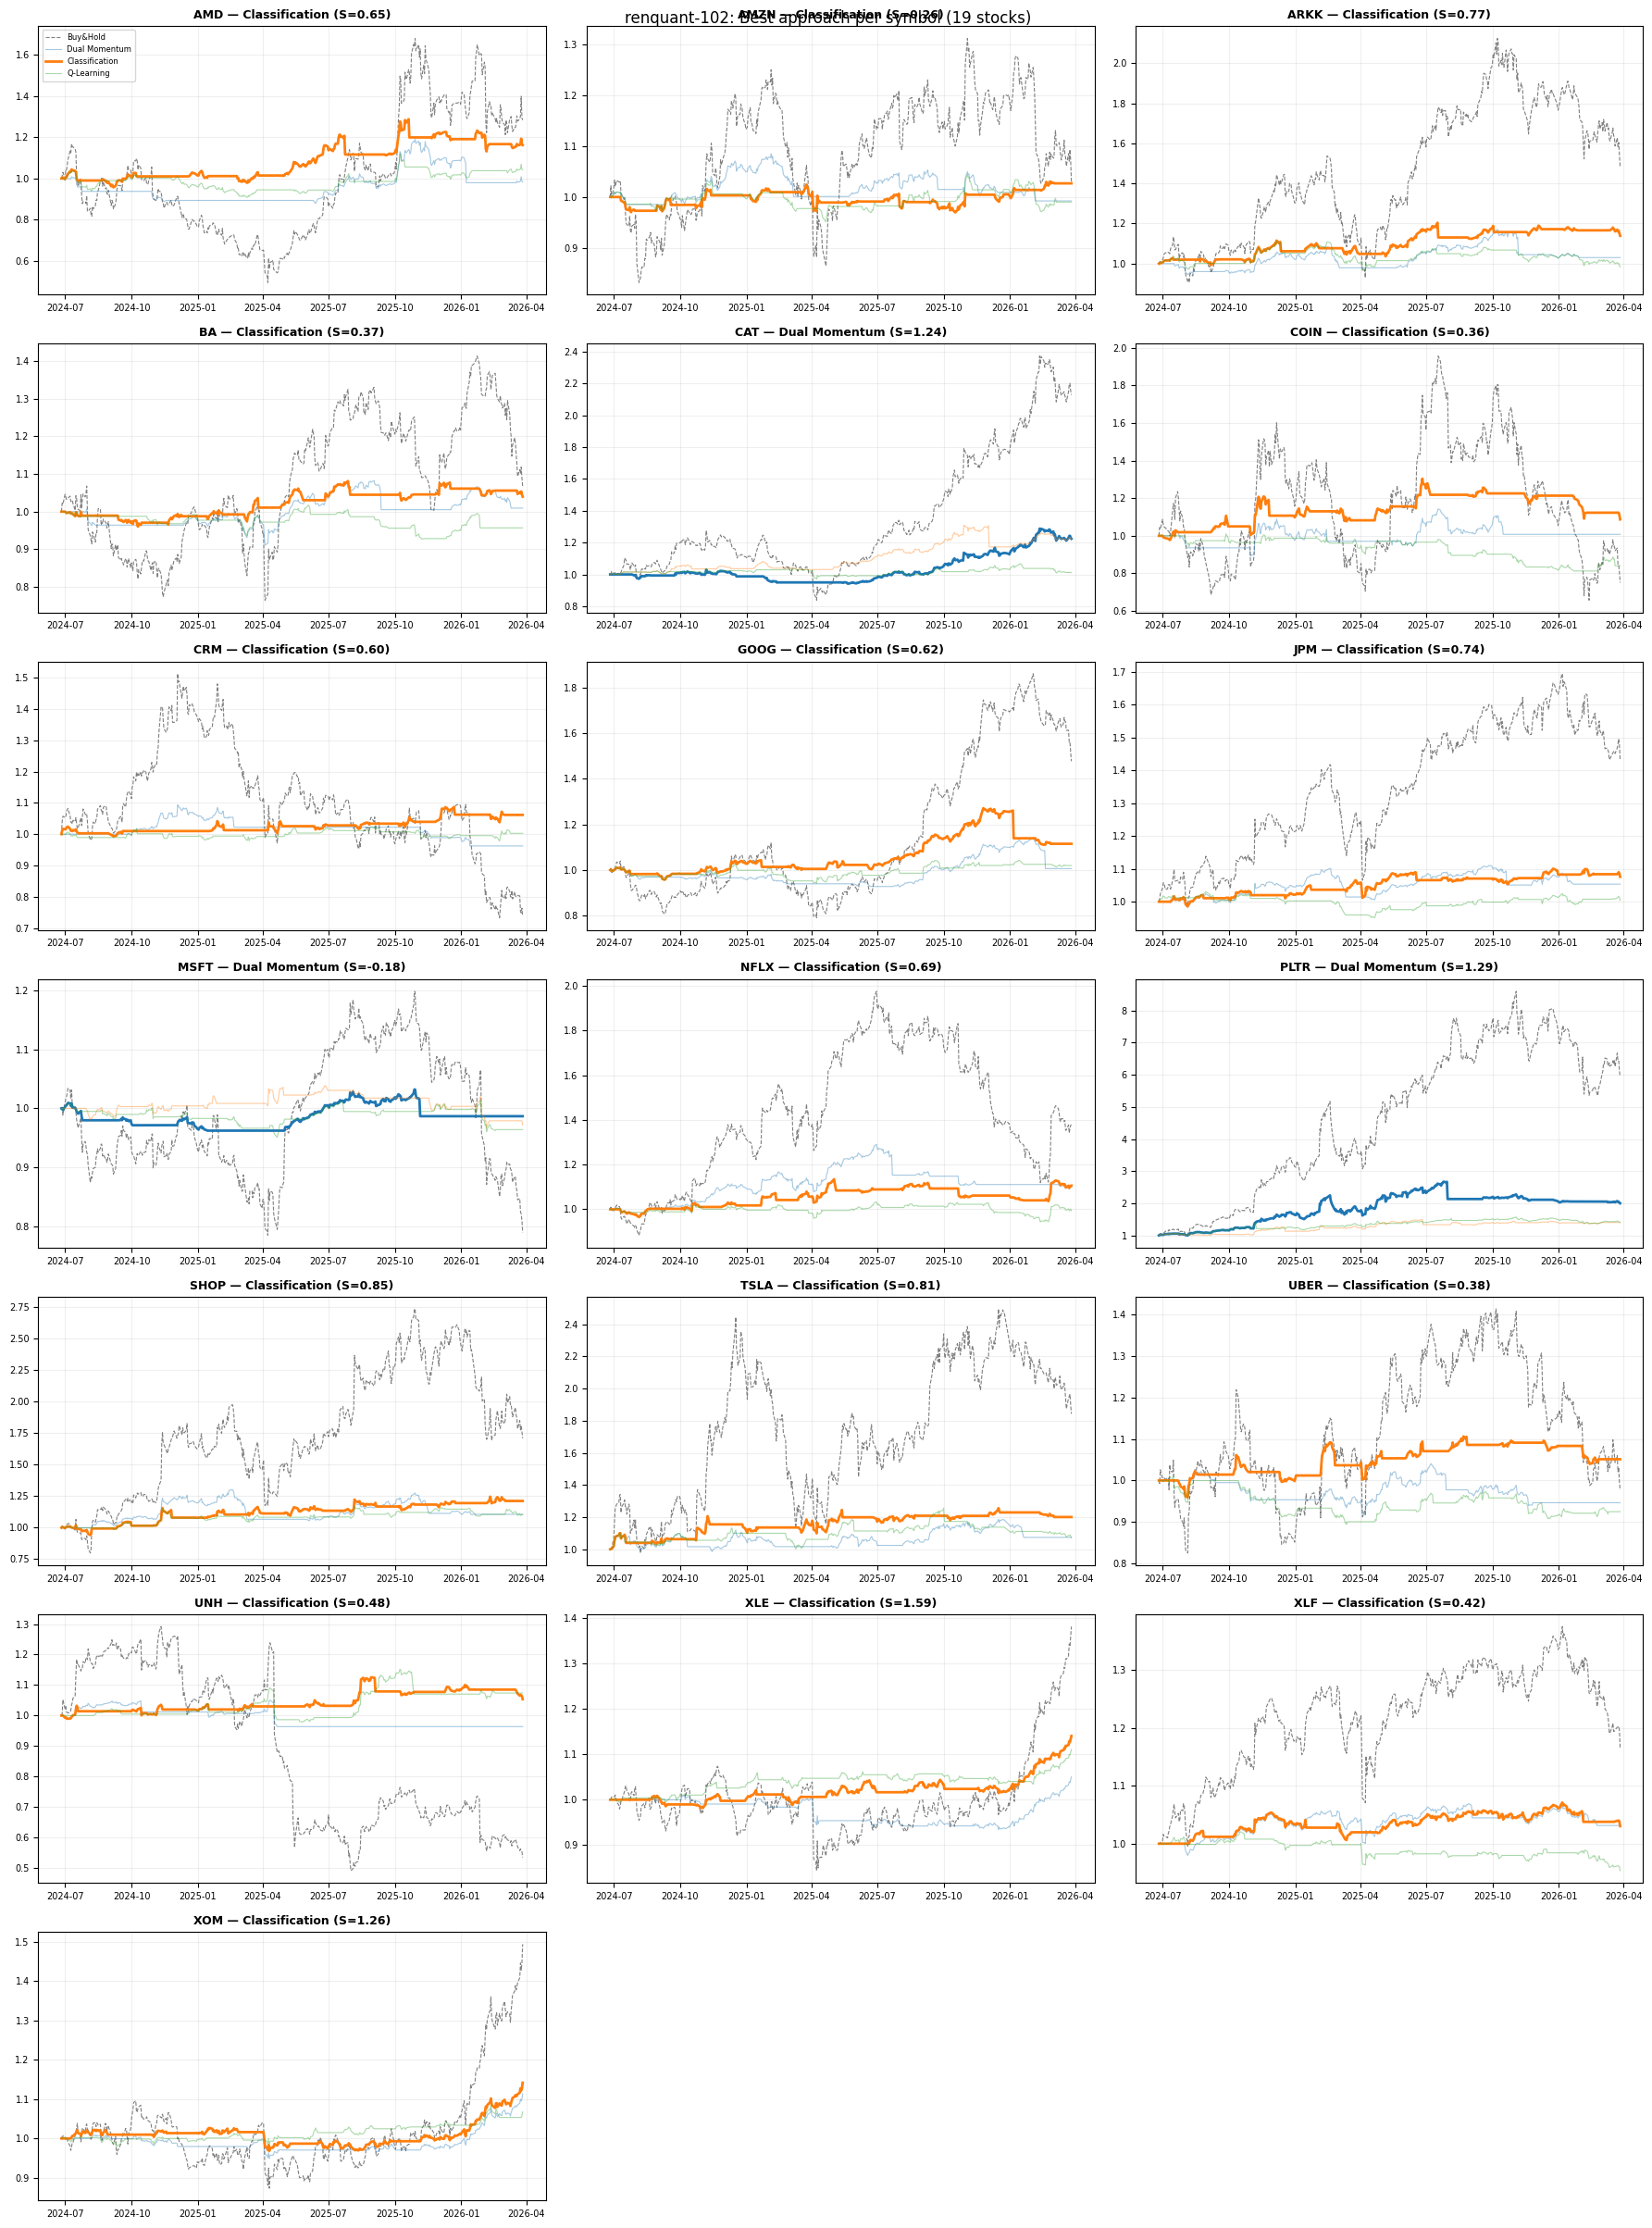

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Per-symbol comparison charts (compact grid)
# ══════════════════════════════════════════════════════════════════════════
symbols_sorted = sorted(results.keys())
n_symbols = len(symbols_sorted)
n_cols = 3
n_rows = (n_symbols + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.5 * n_rows), sharex=False)
axes_flat = axes.flatten() if n_symbols > 1 else [axes]

approach_colors = {
    "Dual Momentum": "tab:blue",
    "Classification": "tab:orange",
    "Q-Learning": "tab:green",
}

for idx, symbol in enumerate(symbols_sorted):
    ax = axes_flat[idx]
    approaches = results[symbol]
    best_name = max(approaches, key=lambda k: approaches[k]["sharpe"])

    df = stock_features[symbol]
    bh = df["close"] / df["close"].iloc[0]
    ax.plot(bh.index, bh, color="gray", linestyle="--", linewidth=0.8, label="Buy&Hold")

    for name, ap in approaches.items():
        norm_eq = ap["equity"] / ap["equity"].iloc[0]
        lw = 2.0 if name == best_name else 0.8
        alpha = 1.0 if name == best_name else 0.4
        ax.plot(norm_eq.index, norm_eq, color=approach_colors[name],
                linewidth=lw, alpha=alpha, label=f"{name}")

    ax.set_title(f"{symbol} — {best_name} (S={approaches[best_name]['sharpe']:.2f})",
                 fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)
    if idx == 0:
        ax.legend(fontsize=6, loc="upper left")

# Hide unused axes
for idx in range(n_symbols, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle(f"renquant-102: Best approach per symbol ({len(results)} stocks)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Cross-symbol summary table
# ══════════════════════════════════════════════════════════════════════════
summary_rows = []
approach_wins = {}

for symbol in sorted(results.keys()):
    approaches = results[symbol]
    best_name = max(approaches, key=lambda k: approaches[k]["sharpe"])
    best = approaches[best_name]
    approach_wins[best_name] = approach_wins.get(best_name, 0) + 1

    hold_days = [(s - b).days for b, s, *_ in best["trades"]]
    summary_rows.append({
        "Symbol": symbol,
        "Best Approach": best_name,
        "Sharpe": round(best["sharpe"], 2),
        "Return": f"{best['return']:.1%}",
        "Round-trips": len(best["trades"]),
        "Avg Hold": f"{np.mean(hold_days):.0f}d" if hold_days else "-",
    })

# Add benchmark row
for symbol in sorted(results.keys()):
    df = stock_features[symbol]
    bh_ret = df["close"].iloc[-1] / df["close"].iloc[0] - 1

summary_df = pd.DataFrame(summary_rows).sort_values("Sharpe", ascending=False)

print("Approach win counts:")
for name, count in sorted(approach_wins.items(), key=lambda x: -x[1]):
    print(f"  {name:16s}: {count}")

print(f"\nTop 10 by Sharpe:")
summary_df.head(10)

Approach win counts:
  Classification  : 16
  Dual Momentum   : 3

Top 10 by Sharpe:


,Symbol,Best Approach,Sharpe,Return,Round-trips,Avg Hold
16,XLE,Classification,1.59,14.0%,6,39d
11,PLTR,Dual Momentum,1.29,100.0%,3,163d
18,XOM,Classification,1.26,14.1%,5,54d
4,CAT,Dual Momentum,1.24,22.4%,3,44d
12,SHOP,Classification,0.85,21.2%,10,31d
13,TSLA,Classification,0.81,20.0%,9,31d
2,ARKK,Classification,0.77,13.9%,9,34d
8,JPM,Classification,0.74,7.6%,8,42d
10,NFLX,Classification,0.69,10.6%,9,29d
0,AMD,Classification,0.65,16.2%,8,38d


In [ ]:
# Full summary table
print(f"All {len(summary_df)} symbols:")
summary_df

All 19 symbols:


,Symbol,Best Approach,Sharpe,Return,Round-trips,Avg Hold
16,XLE,Classification,1.59,14.0%,6,39d
11,PLTR,Dual Momentum,1.29,100.0%,3,163d
18,XOM,Classification,1.26,14.1%,5,54d
4,CAT,Dual Momentum,1.24,22.4%,3,44d
12,SHOP,Classification,0.85,21.2%,10,31d
13,TSLA,Classification,0.81,20.0%,9,31d
2,ARKK,Classification,0.77,13.9%,9,34d
8,JPM,Classification,0.74,7.6%,8,42d
10,NFLX,Classification,0.69,10.6%,9,29d
0,AMD,Classification,0.65,16.2%,8,38d


# ══════════════════════════════════════════════════════════════════════════
# Portfolio-Level Simulation
# ══════════════════════════════════════════════════════════════════════════
# Replicate the LEAN multi-stock strategy logic in Python:
# - Scan volume z-scores daily (bullish days only: close > prev close)
# - Confirm with pre-trained model before entry (Sharpe floor = 0.5)
# - Manage up to 3 concurrent positions
# - Position sizing: max 30% per trade, 0% cash reserve
# - Starting capital: $100,000

In [ ]:
# ── Portfolio simulation mirroring LEAN multi-stock strategy ──────────────
# Parameters
PORT_INITIAL_CASH = 100_000
PORT_MAX_POSITION_PCT = config.get("position_sizing", {}).get("max_position_pct", 0.30)
PORT_CASH_RESERVE_PCT = config.get("position_sizing", {}).get("cash_reserve_pct", 0.00)
PORT_MAX_POSITIONS = config.get("max_concurrent_positions", 3)
PORT_VOLUME_ZSCORE_LOOKBACK = config.get("volume_zscore_lookback", 20)
PORT_VOLUME_ZSCORE_THRESHOLD = config.get("volume_zscore_threshold", 1.5)
PORT_WASH_SALE_DAYS = config.get("wash_sale_days", 30)
PORT_MIN_HOLD_DAYS = config.get("min_hold_days", 3)
PORT_MAX_HOLD_DAYS = config.get("max_hold_days", 500)

# Adaptive volume filter config
vol_filter = config.get("volume_filter", {})
PORT_VOLUME_FILTER_MODE = vol_filter.get("mode", "percentile")
PORT_VOLUME_PERCENTILE_THRESHOLD = float(vol_filter.get("percentile_threshold", 85))

# ── Build a common trading calendar from SPY ─────────────────────────────
trading_days = dfs_raw[BENCHMARK].index.sort_values()

# ── Pre-compute volume scores for all stocks on all days ─────────────────
# Supports both percentile (adaptive per-stock) and z-score (legacy) modes.
volume_scores = {}   # {symbol: Series indexed by date}
volume_triggered = {}  # {symbol: Series of bool indexed by date}

for symbol in stock_features:
    if symbol not in dfs_raw:
        continue
    vol = dfs_raw[symbol]["volume"]

    if PORT_VOLUME_FILTER_MODE == "percentile":
        # Percentile rank: for each day, what % of lookback days had lower volume?
        def rolling_percentile_rank(s, lookback):
            result = pd.Series(np.nan, index=s.index)
            for i in range(lookback, len(s)):
                today = s.iloc[i]
                window = s.iloc[i - lookback:i]
                result.iloc[i] = (window < today).sum() / len(window) * 100
            return result

        scores = rolling_percentile_rank(vol, PORT_VOLUME_ZSCORE_LOOKBACK)
        volume_scores[symbol] = scores.dropna()
        volume_triggered[symbol] = scores >= PORT_VOLUME_PERCENTILE_THRESHOLD
    else:
        # Legacy z-score mode
        vol_mean = vol.rolling(PORT_VOLUME_ZSCORE_LOOKBACK, min_periods=PORT_VOLUME_ZSCORE_LOOKBACK).mean()
        vol_std = vol.rolling(PORT_VOLUME_ZSCORE_LOOKBACK, min_periods=PORT_VOLUME_ZSCORE_LOOKBACK).std()
        scores = ((vol - vol_mean) / vol_std.replace(0, np.nan)).dropna()
        volume_scores[symbol] = scores
        volume_triggered[symbol] = scores >= PORT_VOLUME_ZSCORE_THRESHOLD

print(f"Volume filter mode: {PORT_VOLUME_FILTER_MODE}")
if PORT_VOLUME_FILTER_MODE == "percentile":
    print(f"  Threshold: P{PORT_VOLUME_PERCENTILE_THRESHOLD:.0f} (top {100 - PORT_VOLUME_PERCENTILE_THRESHOLD:.0f}% of days trigger)")
else:
    print(f"  Threshold: z-score >= {PORT_VOLUME_ZSCORE_THRESHOLD}")

# ── Pre-compute daily price direction (bullish = close > prev close) ─────
price_up = {}  # {symbol: Series of bool indexed by date}
for symbol in stock_features:
    if symbol not in dfs_raw:
        continue
    close = dfs_raw[symbol]["close"]
    price_up[symbol] = close > close.shift(1)

# ── Get best model per symbol (same as export logic, with Sharpe floor) ──
MIN_SIM_SHARPE = 0.5
best_models = {}
for symbol in results:
    best_name = max(results[symbol], key=lambda k: results[symbol][k]["sharpe"])
    best = results[symbol][best_name]
    if best["sharpe"] < MIN_SIM_SHARPE:
        continue
    best_models[symbol] = {
        "name": best_name,
        "model": best["model"],
    }

print(f"Models passing Sharpe floor ({MIN_SIM_SHARPE}): {len(best_models)}/{len(results)}")

def model_predict_action(symbol, day_idx, df):
    """Get model action for a symbol on a given day using its feature frame."""
    model_obj = best_models[symbol]["model"]
    single = df.loc[[day_idx]]
    signals = model_obj.predict_bulk(single)
    return signals.iloc[0]

# ── Day-by-day portfolio simulation ──────────────────────────────────────
cash = float(PORT_INITIAL_CASH)
positions = {}       # {symbol: {"shares": int, "entry_date": date, "entry_price": float}}
last_sell_dates = {} # {symbol: date}

equity_history = []
trade_log = []

sim_days = trading_days[trading_days >= trading_days[PORT_VOLUME_ZSCORE_LOOKBACK + 60]]

for day in sim_days:
    # ── Mark-to-market ────────────────────────────────────────────────
    portfolio_value = cash
    for sym, pos in positions.items():
        if day in dfs_raw[sym].index:
            price = dfs_raw[sym].loc[day, "close"]
            portfolio_value += pos["shares"] * price

    # ── Step 1: Process SELLS for held positions ──────────────────────
    for sym in list(positions.keys()):
        if day not in stock_features.get(sym, pd.DataFrame()).index:
            continue

        pos = positions[sym]
        days_held = (day - pos["entry_date"]).days

        # Max hold forced sell
        if PORT_MAX_HOLD_DAYS > 0 and days_held >= PORT_MAX_HOLD_DAYS:
            price = dfs_raw[sym].loc[day, "close"]
            gross_pnl = (price - pos["entry_price"]) * pos["shares"]
            tax = common.compute_trade_tax(gross_pnl, days_held, **TAX_CONFIG)
            cash += pos["shares"] * price - tax
            trade_log.append({
                "symbol": sym, "action": "sell", "date": day,
                "price": price, "shares": pos["shares"],
                "reason": f"max_hold ({days_held}d)",
                "pnl": gross_pnl, "tax": tax, "holding_days": days_held,
            })
            last_sell_dates[sym] = day
            del positions[sym]
            continue

        # Model-driven sell
        if sym not in best_models:
            continue
        action = model_predict_action(sym, day, stock_features[sym])
        if action == "sell":
            # Min hold constraint
            if PORT_MIN_HOLD_DAYS > 0 and days_held < PORT_MIN_HOLD_DAYS:
                continue
            price = dfs_raw[sym].loc[day, "close"]
            gross_pnl = (price - pos["entry_price"]) * pos["shares"]
            tax = common.compute_trade_tax(gross_pnl, days_held, **TAX_CONFIG)
            cash += pos["shares"] * price - tax
            trade_log.append({
                "symbol": sym, "action": "sell", "date": day,
                "price": price, "shares": pos["shares"],
                "reason": f"model_sell ({days_held}d)",
                "pnl": gross_pnl, "tax": tax, "holding_days": days_held,
            })
            last_sell_dates[sym] = day
            del positions[sym]

    # ── Step 2: Count open slots ──────────────────────────────────────
    open_slots = PORT_MAX_POSITIONS - len(positions)

    # ── Step 3: DETECT — scan volume (adaptive per-stock filter) ──────
    if open_slots > 0:
        candidates = []
        for sym in best_models:
            if sym in positions:
                continue
            if sym not in volume_triggered or day not in volume_triggered[sym].index:
                continue
            if not volume_triggered[sym].loc[day]:
                continue
            score = volume_scores[sym].loc[day]
            if np.isnan(score):
                continue
            # Bullish filter: only enter on up-close days
            if sym in price_up and day in price_up[sym].index and not price_up[sym].loc[day]:
                continue
            candidates.append((sym, score))

        # Rank by volume score descending (highest activity first)
        candidates.sort(key=lambda x: x[1], reverse=True)

        # ── Step 4: CONFIRM + EXECUTE ─────────────────────────────────
        for sym, vol_score in candidates:
            if open_slots <= 0:
                break

            # Wash sale check
            if sym in last_sell_dates:
                if (day - last_sell_dates[sym]).days < PORT_WASH_SALE_DAYS:
                    continue

            # Model confirmation
            if day not in stock_features[sym].index:
                continue
            action = model_predict_action(sym, day, stock_features[sym])
            if action != "buy":
                continue

            # Position sizing
            portfolio_value = cash + sum(
                pos["shares"] * dfs_raw[s].loc[day, "close"]
                for s, pos in positions.items()
                if day in dfs_raw[s].index
            )
            cash_reserve = portfolio_value * PORT_CASH_RESERVE_PCT
            investable = max(cash - cash_reserve, 0)
            max_invest = portfolio_value * PORT_MAX_POSITION_PCT
            invest_amount = min(max_invest, investable)

            price = dfs_raw[sym].loc[day, "close"]
            shares = int(invest_amount // price)
            if shares <= 0:
                continue

            cash -= shares * price
            positions[sym] = {
                "shares": shares,
                "entry_date": day,
                "entry_price": price,
            }
            score_label = f"pct={vol_score:.0f}" if PORT_VOLUME_FILTER_MODE == "percentile" else f"zscore={vol_score:.2f}"
            trade_log.append({
                "symbol": sym, "action": "buy", "date": day,
                "price": price, "shares": shares,
                "reason": score_label,
                "pnl": 0, "tax": 0, "holding_days": 0,
            })
            open_slots -= 1

    # ── Record daily equity ───────────────────────────────────────────
    eod_value = cash
    for sym, pos in positions.items():
        if day in dfs_raw[sym].index:
            eod_value += pos["shares"] * dfs_raw[sym].loc[day, "close"]
    equity_history.append({"date": day, "equity": eod_value, "positions": len(positions), "cash": cash})

equity_df = pd.DataFrame(equity_history).set_index("date")
trade_df = pd.DataFrame(trade_log) if trade_log else pd.DataFrame()

print(f"Simulation: {sim_days[0].strftime('%Y-%m-%d')} -> {sim_days[-1].strftime('%Y-%m-%d')}")
print(f"Volume filter: {PORT_VOLUME_FILTER_MODE} (threshold: {'P' + str(int(PORT_VOLUME_PERCENTILE_THRESHOLD)) if PORT_VOLUME_FILTER_MODE == 'percentile' else str(PORT_VOLUME_ZSCORE_THRESHOLD)})")
print(f"Tax: short-term {TAX_CONFIG['short_term_rate']:.0%}, long-term {TAX_CONFIG['long_term_rate']:.0%}")
print(f"Max hold: {PORT_MAX_HOLD_DAYS}d  |  Cash reserve: {PORT_CASH_RESERVE_PCT:.0%}  |  Max position: {PORT_MAX_POSITION_PCT:.0%}")
print(f"Total trades: {len(trade_df)}")
if len(trade_df) > 0:
    buys = trade_df[trade_df["action"] == "buy"]
    sells = trade_df[trade_df["action"] == "sell"]
    print(f"  Buys:  {len(buys)}")
    print(f"  Sells: {len(sells)}")
    total_gross = sells["pnl"].sum() if len(sells) > 0 else 0
    total_tax = sells["tax"].sum() if len(sells) > 0 else 0
    n_short = sum(1 for _, r in sells.iterrows() if r["holding_days"] < TAX_CONFIG["long_term_threshold_days"])
    n_long = len(sells) - n_short
    print(f"  Gross P&L:     ${total_gross:,.2f}")
    print(f"  Tax paid:      ${total_tax:,.2f}  (ST: {n_short}, LT: {n_long})")
    print(f"  After-tax P&L: ${total_gross - total_tax:,.2f}")
print(f"Final equity: ${equity_df['equity'].iloc[-1]:,.2f}  (after tax)")
print(f"Return: {equity_df['equity'].iloc[-1] / PORT_INITIAL_CASH - 1:.2%}")

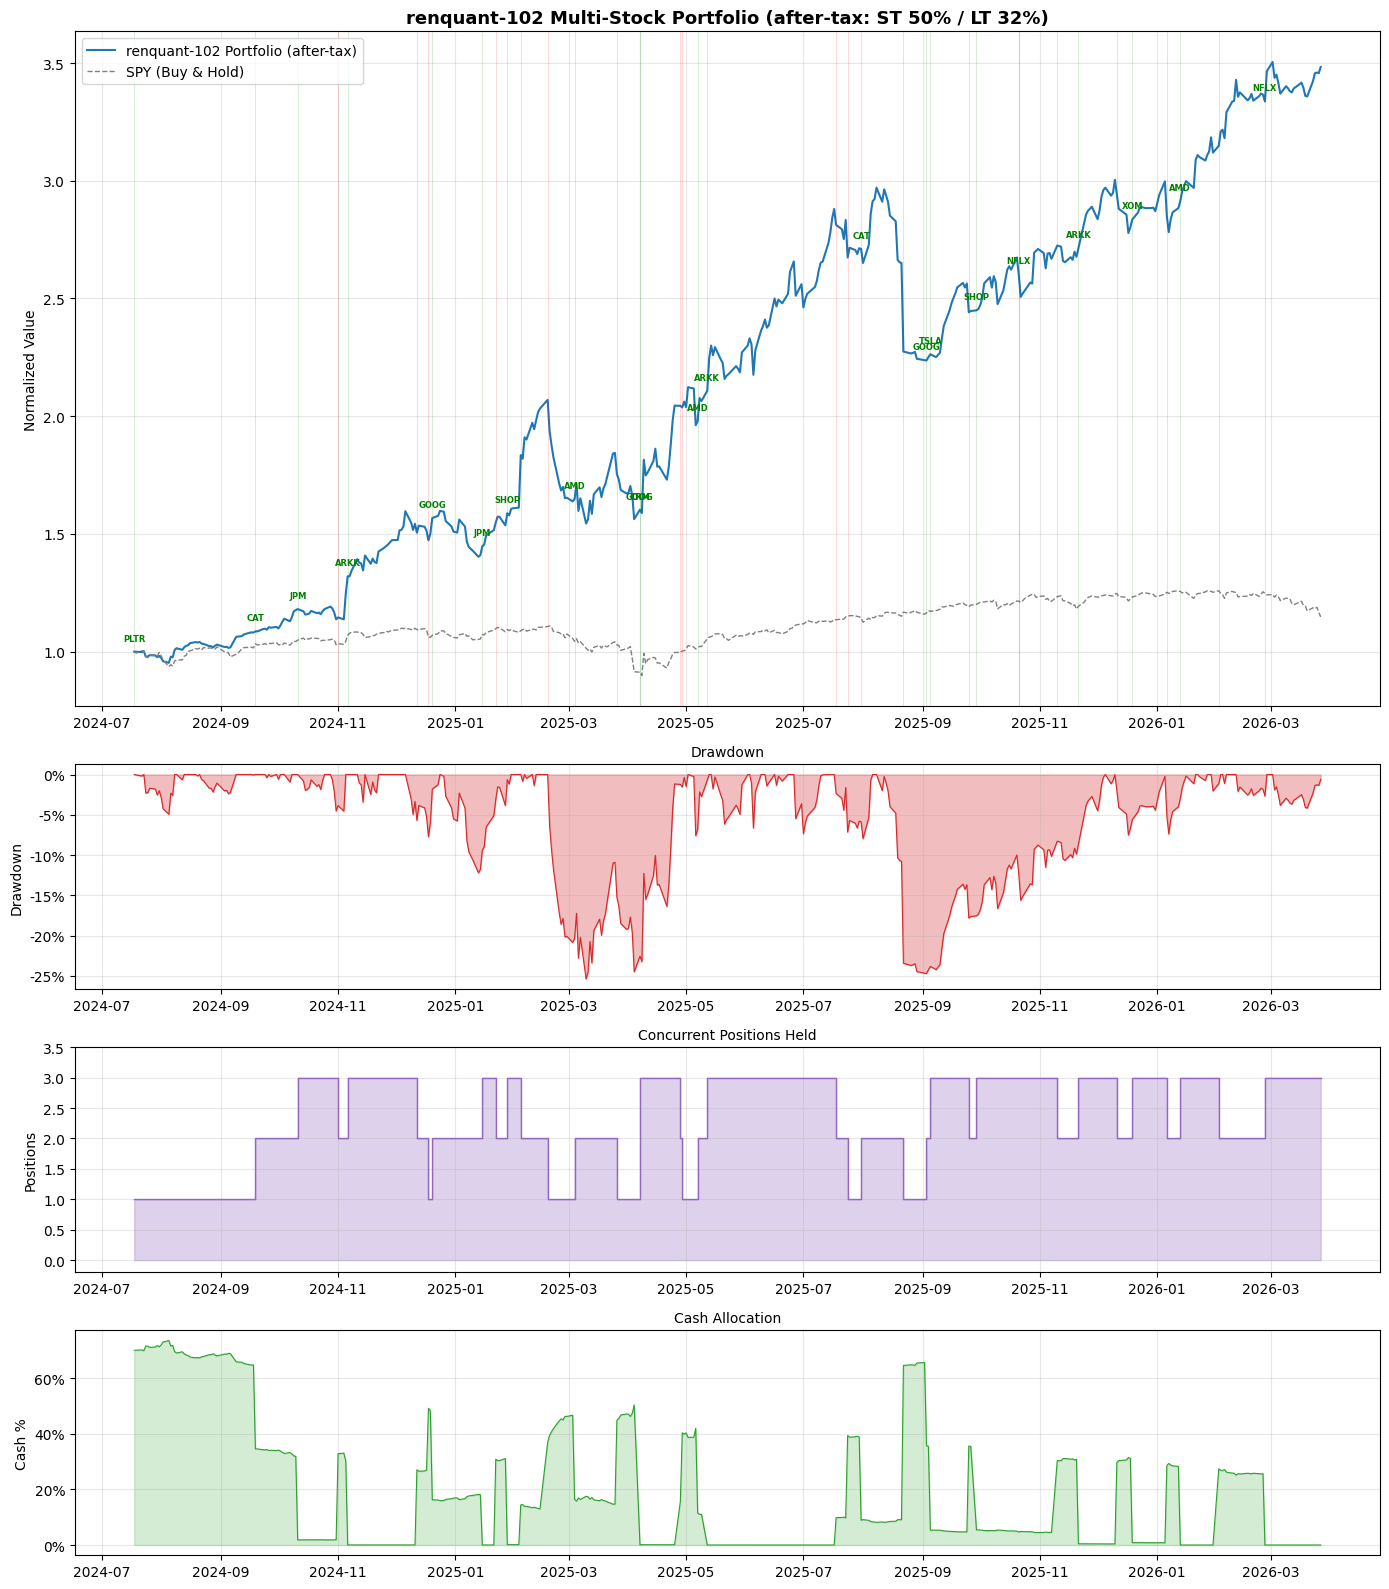


Portfolio Performance Summary (After-Tax)
Initial Capital:    $  100,000.00
Final Equity:       $  348,299.80
Total Return:            248.30%
SPY Return:               14.75%
Excess Return:           233.55%
Sharpe Ratio:               2.11
Max Drawdown:            -25.38%
Round-trips:                  18
Gross P&L:          $  263,854.29
Tax Paid:           $  111,626.46
After-Tax P&L:      $  152,227.83
Effective Tax Rate:          42%


In [ ]:
# ── Portfolio performance dashboard ─────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 16), gridspec_kw={"height_ratios": [3, 1, 1, 1]})

# Panel 1: Equity curve vs SPY benchmark
ax1 = axes[0]
norm_eq = equity_df["equity"] / PORT_INITIAL_CASH
spy_prices = dfs_raw[BENCHMARK].loc[equity_df.index, "close"]
norm_spy = spy_prices / spy_prices.iloc[0]

ax1.plot(norm_eq.index, norm_eq, color="tab:blue", linewidth=1.5, label="renquant-102 Portfolio (after-tax)")
ax1.plot(norm_spy.index, norm_spy, color="gray", linewidth=1, linestyle="--", label=f"{BENCHMARK} (Buy & Hold)")

# Mark buy/sell trades on equity curve
if len(trade_df) > 0:
    buys = trade_df[trade_df["action"] == "buy"]
    sells = trade_df[trade_df["action"] == "sell"]
    for _, t in buys.iterrows():
        if t["date"] in equity_df.index:
            ax1.axvline(t["date"], color="green", alpha=0.15, linewidth=0.8)
    for _, t in sells.iterrows():
        if t["date"] in equity_df.index:
            ax1.axvline(t["date"], color="red", alpha=0.15, linewidth=0.8)

# Annotate buy markers with symbol labels
if len(trade_df) > 0:
    for _, t in buys.iterrows():
        if t["date"] in equity_df.index:
            y = equity_df.loc[t["date"], "equity"] / PORT_INITIAL_CASH
            ax1.annotate(t["symbol"], xy=(t["date"], y), fontsize=6,
                         color="green", fontweight="bold", ha="center",
                         xytext=(0, 8), textcoords="offset points")

ax1.set_title(f"renquant-102 Multi-Stock Portfolio (after-tax: "
              f"ST {TAX_CONFIG['short_term_rate']:.0%} / LT {TAX_CONFIG['long_term_rate']:.0%})",
              fontsize=13, fontweight="bold")
ax1.set_ylabel("Normalized Value")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# Panel 2: Drawdown
peak = equity_df["equity"].cummax()
drawdown = (equity_df["equity"] - peak) / peak
ax2 = axes[1]
ax2.fill_between(drawdown.index, drawdown, 0, color="tab:red", alpha=0.3)
ax2.plot(drawdown.index, drawdown, color="tab:red", linewidth=0.8)
ax2.set_ylabel("Drawdown")
ax2.set_title("Drawdown", fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# Panel 3: Number of positions held
ax3 = axes[2]
ax3.fill_between(equity_df.index, equity_df["positions"], 0, color="tab:purple", alpha=0.3, step="post")
ax3.step(equity_df.index, equity_df["positions"], color="tab:purple", linewidth=1, where="post")
ax3.set_ylabel("Positions")
ax3.set_title("Concurrent Positions Held", fontsize=10)
ax3.set_ylim(-0.2, PORT_MAX_POSITIONS + 0.5)
ax3.grid(True, alpha=0.3)

# Panel 4: Cash allocation
ax4 = axes[3]
cash_pct = equity_df["cash"] / equity_df["equity"]
ax4.fill_between(equity_df.index, cash_pct, 0, color="tab:green", alpha=0.2)
ax4.plot(equity_df.index, cash_pct, color="tab:green", linewidth=0.8)
if PORT_CASH_RESERVE_PCT > 0:
    ax4.axhline(PORT_CASH_RESERVE_PCT, color="orange", linestyle="--", linewidth=0.8,
                label=f"Reserve ({PORT_CASH_RESERVE_PCT:.0%})")
    ax4.legend(fontsize=8)
ax4.set_ylabel("Cash %")
ax4.set_title("Cash Allocation", fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()

# ── Summary stats ────────────────────────────────────────────────────────
total_return = equity_df["equity"].iloc[-1] / PORT_INITIAL_CASH - 1
spy_return = norm_spy.iloc[-1] - 1
daily_rets = equity_df["equity"].pct_change().dropna()
sharpe = daily_rets.mean() / daily_rets.std() * np.sqrt(252) if daily_rets.std() > 0 else 0
max_dd = drawdown.min()

total_tax = 0
total_gross = 0
n_sells = 0
if len(trade_df) > 0:
    sells_df = trade_df[trade_df["action"] == "sell"]
    n_sells = len(sells_df)
    total_gross = sells_df["pnl"].sum()
    total_tax = sells_df["tax"].sum()

print(f"\n{'='*55}")
print(f"Portfolio Performance Summary (After-Tax)")
print(f"{'='*55}")
print(f"Initial Capital:    ${PORT_INITIAL_CASH:>12,.2f}")
print(f"Final Equity:       ${equity_df['equity'].iloc[-1]:>12,.2f}")
print(f"Total Return:       {total_return:>12.2%}")
print(f"SPY Return:         {spy_return:>12.2%}")
print(f"Excess Return:      {total_return - spy_return:>12.2%}")
print(f"Sharpe Ratio:       {sharpe:>12.2f}")
print(f"Max Drawdown:       {max_dd:>12.2%}")
print(f"Round-trips:        {n_sells:>12d}")
print(f"Gross P&L:          ${total_gross:>12,.2f}")
print(f"Tax Paid:           ${total_tax:>12,.2f}")
print(f"After-Tax P&L:      ${total_gross - total_tax:>12,.2f}")
eff_rate = total_tax / total_gross if total_gross > 0 else 0
print(f"Effective Tax Rate: {eff_rate:>12.0%}")
print(f"{'='*55}")

In [ ]:
# ── Trade log detail ──────────────────────────────────────────────────────
if len(trade_df) > 0:
    display_df = trade_df.copy()
    display_df["date"] = display_df["date"].dt.strftime("%Y-%m-%d")
    display_df["price"] = display_df["price"].map("${:,.2f}".format)
    display_df["pnl"] = display_df["pnl"].map("${:,.2f}".format)
    display_df["tax"] = display_df["tax"].map("${:,.2f}".format)
    display_df["tax_type"] = display_df["holding_days"].apply(
        lambda d: "LT" if d >= TAX_CONFIG["long_term_threshold_days"] else "ST"
    )
    print("Trade Log (after-tax):")
    display(display_df[["date", "symbol", "action", "shares", "price", "reason",
                        "holding_days", "pnl", "tax", "tax_type"]])
else:
    print("No trades executed — the volume z-score threshold was never met.")
    print(f"\nVolume z-score distribution (max per day across all stocks):")
    daily_max_zscores = []
    for day in sim_days:
        day_max = -999
        for sym in volume_zscores:
            if day in volume_zscores[sym].index:
                z = volume_zscores[sym].loc[day]
                if not np.isnan(z) and z > day_max:
                    day_max = z
        if day_max > -999:
            daily_max_zscores.append(day_max)

    zs = pd.Series(daily_max_zscores)
    print(f"  Mean:   {zs.mean():.2f}")
    print(f"  Median: {zs.median():.2f}")
    print(f"  P90:    {zs.quantile(0.90):.2f}")
    print(f"  P95:    {zs.quantile(0.95):.2f}")
    print(f"  P99:    {zs.quantile(0.99):.2f}")
    print(f"  Max:    {zs.max():.2f}")
    print(f"\n  Current threshold: {PORT_VOLUME_ZSCORE_THRESHOLD}")
    print(f"  Suggestion: try lowering to {zs.quantile(0.90):.1f} (P90) or {zs.quantile(0.80):.1f} (P80)")

Trade Log (after-tax):


,date,symbol,action,shares,price,reason,holding_days,pnl,tax,tax_type
0,2024-07-18,PLTR,buy,1047,$28.64,zscore=2.08,0,$0.00,$0.00,ST
1,2024-09-19,CAT,buy,87,$373.31,zscore=2.52,0,$0.00,$0.00,ST
2,2024-10-11,JPM,buy,159,$222.29,zscore=3.34,0,$0.00,$0.00,ST
3,2024-11-01,JPM,sell,159,$222.94,model_sell (21d),21,$103.35,$51.68,ST
4,2024-11-06,ARKK,buy,720,$52.14,zscore=2.99,0,$0.00,$0.00,ST
5,2024-12-12,ARKK,sell,720,$60.92,model_sell (36d),36,"$6,321.60","$3,160.80",ST
6,2024-12-18,CAT,sell,87,$363.89,model_sell (90d),90,$-819.54,$0.00,ST
7,2024-12-20,GOOG,buy,243,$192.96,zscore=2.08,0,$0.00,$0.00,ST
8,2025-01-15,JPM,buy,101,$252.35,zscore=2.65,0,$0.00,$0.00,ST
9,2025-01-22,GOOG,sell,243,$200.03,model_sell (33d),33,"$1,718.01",$859.00,ST
